# Laboratorio 5 - Naive Bayes

Este notebook cubre los primeros cinco incisos del laboratorio:

1. Construir un modelo de regresion con Naive Bayes para predecir `price`.
2. Evaluar que tan bien funciona usando metricas correctas de regresion.
3. Comparar Naive Bayes contra regresion lineal y arbol de regresion.
4. Construir un modelo de clasificacion usando la categoria de precio.
5. Utilizar los modelos con el conjunto de prueba y determinar la eficiencia del algoritmo para predecir y clasificar.

## Estructura

1. Imports y configuracion
2. Carga de datos
3. Preparacion de datos
4. Inciso 1 - Modelo de Regresion con Naive Bayes
5. Inciso 2 - Evaluacion del Modelo de Regresion
6. Inciso 3 - Comparacion con Regresion Lineal y Arbol de Regresion
7. Inciso 4 - Modelo de Clasificacion con Categoria de Precio
8. Inciso 5 - Eficiencia del Algoritmo para Predecir y Clasificar

In [100]:
%pip install pyreadr pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Imports y Configuracion

In [101]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

DATA_PATH = Path("listings.RData")
RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## Carga de Datos

Cargamos el archivo `listings.RData` y verificamos el objeto principal.

In [102]:
result = pyreadr.read_r(DATA_PATH)
print("Objetos encontrados en el RData:")
print(list(result.keys()))

df = result["listings"].copy()
print(f"Dimensiones del DataFrame: {df.shape}")
display(df.head())

Objetos encontrados en el RData:
['listings']
Dimensiones del DataFrame: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6

## Preparacion de Datos

Trabajaremos con predictores numericos. Tambien limpiamos la variable `price`, excluimos identificadores y preparamos el mismo `train/test split` para que las comparaciones entre modelos sean validas.

In [103]:
def clean_price(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")


df["price_num"] = clean_price(df["price"])

excluded_features = {
    "price_num",
    "id",
    "scrape_id",
    "host_id",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
}

feature_columns = [
    column
    for column in df.select_dtypes(include="number").columns
    if column not in excluded_features
]

df_model = df[feature_columns + ["price_num"]].dropna(subset=["price_num"]).copy()

X = df_model[feature_columns]
y_price = df_model["price_num"]
y_log = np.log1p(y_price)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print(f"Filas para modelar: {len(df_model):,}")
print(f"Predictores numericos usados: {len(feature_columns)}")
print("\nVariables predictoras:")
print(feature_columns)

display(y_price.describe().to_frame(name="price_num"))

Filas para modelar: 76,246
Predictores numericos usados: 29

Variables predictoras:
['latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']


/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
25%,120.000000
50%,193.000000
75%,326.000000
max,50123.000000


## Inciso 1 - Modelo de Regresion con Naive Bayes

Como `scikit-learn` no incluye un regresor de Naive Bayes nativo, usamos una aproximacion mas estable y facil de interpretar:

- transformamos la respuesta a `log(1 + price)`,
- dividimos esa respuesta en intervalos por cuantiles,
- entrenamos `GaussianNB` para predecir el intervalo,
- y luego convertimos las probabilidades de cada intervalo en un precio representativo usando la mediana del intervalo.

Intervalos usados para Naive Bayes: 5


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: divide by zero encountered in matmul
  return class_probabilities @ self.class_value_medians_
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: overflow encountered in matmul
  return class_probabilities @ self.class_value_medians_
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: invalid value encountered in matmul
  return class_probabilities @ self.class_value_medians_


,price_real,price_predicho,error_abs,caso
0,255.0,80.044657,174.955343,Caso 1
1,955.0,80.044717,874.955283,Caso 2
2,198.0,80.044652,117.955348,Caso 3
3,165.0,80.044562,84.955438,Caso 4
4,152.0,80.044615,71.955385,Caso 5
5,336.0,80.044630,255.955370,Caso 6
6,239.0,80.044780,158.955220,Caso 7
7,302.0,80.044721,221.955279,Caso 8
8,277.0,80.044649,196.955351,Caso 9
9,192.0,80.044652,111.955348,Caso 10


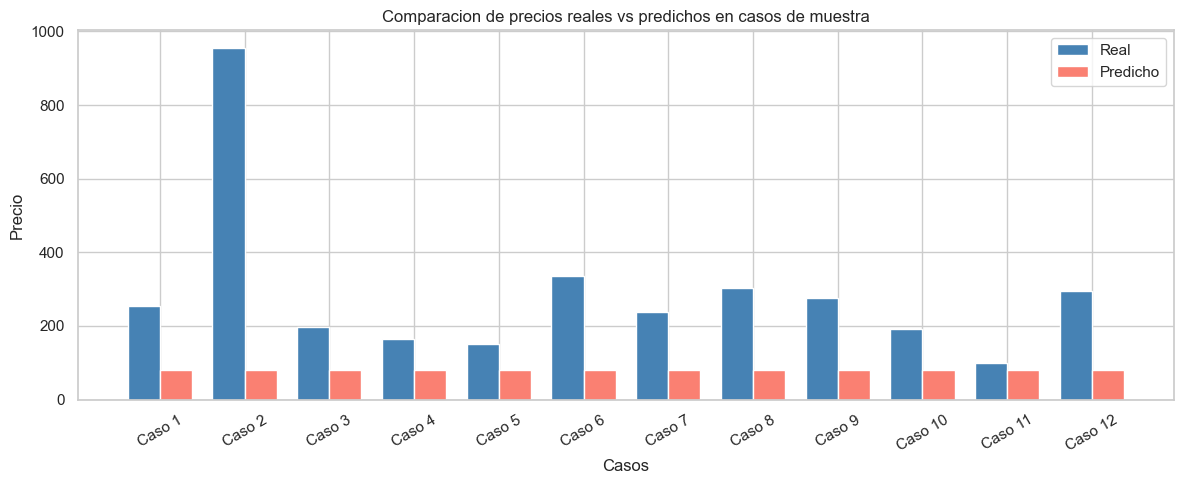

In [104]:
class QuantileNaiveBayesRegressor:
    def __init__(self, n_bins: int = 5, var_smoothing: float = 1e-8):
        self.n_bins = n_bins
        self.var_smoothing = var_smoothing

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_unique = np.unique(y).size
        self.n_bins_ = min(self.n_bins, max(2, n_unique))

        y_bins, self.bin_edges_ = pd.qcut(
            pd.Series(y),
            q=self.n_bins_,
            labels=False,
            retbins=True,
            duplicates="drop",
        )
        y_bins = np.asarray(y_bins, dtype=int)

        self.model_ = GaussianNB(var_smoothing=self.var_smoothing)
        self.model_.fit(X, y_bins)

        self.classes_ = self.model_.classes_
        self.class_value_medians_ = np.array(
            [np.median(y[y_bins == class_id]) for class_id in self.classes_]
        )
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        class_probabilities = self.model_.predict_proba(X)
        return class_probabilities @ self.class_value_medians_


nb_regressor = QuantileNaiveBayesRegressor(n_bins=5, var_smoothing=1e-8)
nb_regressor.fit(X_train_imp, y_train_log)

y_pred_log = nb_regressor.predict(X_test_imp)
y_pred_price = np.clip(np.expm1(y_pred_log), 0, None)
y_test_price = np.expm1(y_test_log)

print(f"Intervalos usados para Naive Bayes: {nb_regressor.n_bins_}")

results_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
    }
)
results_df["error_abs"] = (results_df["price_real"] - results_df["price_predicho"]).abs()

visual_sample = results_df.sample(12, random_state=RANDOM_STATE).reset_index(drop=True)
visual_sample["caso"] = [f"Caso {i + 1}" for i in range(len(visual_sample))]

display(visual_sample)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(visual_sample))
width = 0.38

ax.bar(x - width / 2, visual_sample["price_real"], width, label="Real", color="steelblue")
ax.bar(x + width / 2, visual_sample["price_predicho"], width, label="Predicho", color="salmon")

ax.set_title("Comparacion de precios reales vs predichos en casos de muestra")
ax.set_xlabel("Casos")
ax.set_ylabel("Precio")
ax.set_xticks(x)
ax.set_xticklabels(visual_sample["caso"], rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

## Inciso 2 - Evaluacion del Modelo de Regresion

Evaluamos el modelo con `MAE`, `RMSE` y `R2`, y lo comparamos con un baseline que siempre predice el precio promedio.

,modelo,MAE,RMSE,R2
0,Naive Bayes Regresion,697.5745,4371.4424,-0.0258
1,Baseline promedio,1017.7531,4316.1287,0.0000


,quintil,precio_real_medio,precio_predicho_medio,mae_promedio,conteo
0,"(12.999, 109.0]",76.77,80.04,18.63,3090
1,"(109.0, 163.0]",135.31,80.04,55.26,3037
2,"(163.0, 231.0]",194.39,80.34,114.08,3034
3,"(231.0, 389.2]",295.37,80.19,215.18,3039
4,"(389.2, 50020.0]",3166.18,80.08,3086.09,3050


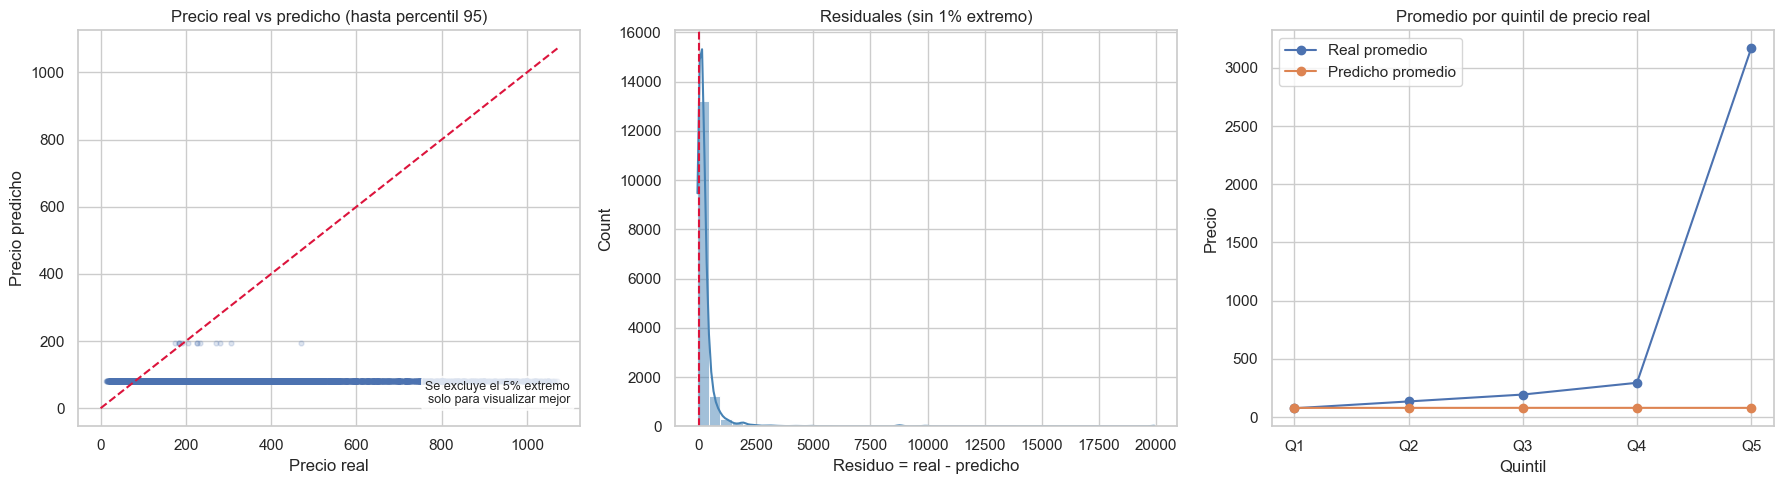

In [105]:
baseline_pred = np.repeat(y_test_price.mean(), len(y_test_price))

metrics_df = pd.DataFrame(
    {
        "modelo": ["Naive Bayes Regresion", "Baseline promedio"],
        "MAE": [
            mean_absolute_error(y_test_price, y_pred_price),
            mean_absolute_error(y_test_price, baseline_pred),
        ],
        "RMSE": [
            mean_squared_error(y_test_price, y_pred_price) ** 0.5,
            mean_squared_error(y_test_price, baseline_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_test_price, y_pred_price),
            r2_score(y_test_price, baseline_pred),
        ],
    }
)

display(metrics_df.round(4))

eval_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
        "baseline": baseline_pred,
    }
)
eval_df["residuo"] = eval_df["price_real"] - eval_df["price_predicho"]
eval_df["error_abs"] = eval_df["residuo"].abs()

price_limit = eval_df["price_real"].quantile(0.95)
residual_limit = eval_df["residuo"].abs().quantile(0.99)

quintile_summary = (
    eval_df.assign(quintil=pd.qcut(eval_df["price_real"], q=5, duplicates="drop"))
    .groupby("quintil", observed=False)
    .agg(
        precio_real_medio=("price_real", "mean"),
        precio_predicho_medio=("price_predicho", "mean"),
        mae_promedio=("error_abs", "mean"),
        conteo=("price_real", "size"),
    )
    .reset_index()
)

display(quintile_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mask_plot = eval_df["price_real"] <= price_limit
axes[0].scatter(
    eval_df.loc[mask_plot, "price_real"],
    eval_df.loc[mask_plot, "price_predicho"],
    alpha=0.18,
    s=12,
)
axes[0].plot([0, price_limit], [0, price_limit], color="crimson", linestyle="--")
axes[0].set_title("Precio real vs predicho (hasta percentil 95)")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")
axes[0].text(
    0.98,
    0.05,
    "Se excluye el 5% extremo\nsolo para visualizar mejor",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

residual_plot = eval_df.loc[eval_df["residuo"].abs() <= residual_limit, "residuo"]
sns.histplot(residual_plot, bins=40, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_title("Residuales (sin 1% extremo)")
axes[1].set_xlabel("Residuo = real - predicho")

x_quintiles = np.arange(len(quintile_summary))
axes[2].plot(x_quintiles, quintile_summary["precio_real_medio"], marker="o", label="Real promedio")
axes[2].plot(x_quintiles, quintile_summary["precio_predicho_medio"], marker="o", label="Predicho promedio")
axes[2].set_xticks(x_quintiles)
axes[2].set_xticklabels([f"Q{i + 1}" for i in x_quintiles])
axes[2].set_title("Promedio por quintil de precio real")
axes[2].set_xlabel("Quintil")
axes[2].set_ylabel("Precio")
axes[2].legend()

plt.tight_layout()
plt.show()

### Interpretacion Inicial

Con esta configuracion, la clave del inciso 2 es mirar tres cosas al mismo tiempo: las metricas globales, la grafica real vs predicho y el resumen por quintiles. Si la linea de `precio_predicho_promedio` se mantiene casi plana mientras el `precio_real_promedio` sube, eso indica que Naive Bayes se esta concentrando en un rango estrecho de valores y no logra capturar bien la variabilidad real del precio.

## Inciso 3 - Comparacion con los Modelos del Lab 4

Para este inciso retomamos los modelos del laboratorio anterior y los comparamos contra Naive Bayes dentro del mismo notebook.

La idea es que la comparacion sea fiel a lo que ya hicimos en `lab4.ipynb`, pero ahora quitando variables con posible fuga de informacion. Por eso aqui reconstruimos:

- el mismo criterio de limpieza del Lab 4,
- el split `70/30` con `random_state = 42`,
- la regresion lineal del Lab 4,
- el mejor arbol del Lab 4 (`max_depth = 20`, `min_samples_leaf = 1`, `min_samples_split = 2`),
- una exclusion adicional de variables demasiado cercanas al precio: `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d`.

Despues reentrenamos Naive Bayes sobre esa misma base para que la comparacion sea justa y mas realista.


In [106]:
df_lab4 = df.copy()
df_lab4["price"] = clean_price(df_lab4["price"])
df_lab4 = df_lab4.dropna(subset=["price"]).copy()

cols_drop_lab4 = [
    "id",
    "listing_url",
    "scrape_id",
    "last_scraped",
    "source",
    "name",
    "description",
    "neighborhood_overview",
    "picture_url",
    "host_url",
    "host_name",
    "host_since",
    "host_location",
    "host_about",
    "host_thumbnail_url",
    "host_picture_url",
    "host_verifications",
    "neighbourhood",
    "calendar_updated",
    "calendar_last_scraped",
    "first_review",
    "last_review",
    "license",
    "bathrooms_text",
    "amenities",
    "avail_group",
]
cols_drop_lab4 = [column for column in cols_drop_lab4 if column in df_lab4.columns]
df_model_lab4 = df_lab4.drop(columns=cols_drop_lab4).copy()

high_null_lab4 = df_model_lab4.isnull().mean()
cols_high_lab4 = high_null_lab4[high_null_lab4 > 0.50].index.tolist()
df_model_lab4 = df_model_lab4.drop(columns=cols_high_lab4)

bool_cols_lab4 = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability",
    "instant_bookable",
]
for column in bool_cols_lab4:
    if column in df_model_lab4.columns:
        df_model_lab4[column] = df_model_lab4[column].map({"t": 1, "f": 0})

for column in ["host_response_rate", "host_acceptance_rate"]:
    if column in df_model_lab4.columns:
        df_model_lab4[column] = pd.to_numeric(
            df_model_lab4[column].astype(str).str.replace("%", "").str.strip(),
            errors="coerce",
        ) / 100

cols_numeric_lab4 = [
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "host_listings_count",
    "host_total_listings_count",
]
for column in cols_numeric_lab4:
    if column in df_model_lab4.columns:
        df_model_lab4[column] = pd.to_numeric(df_model_lab4[column], errors="coerce")

num_cols_lab4 = df_model_lab4.select_dtypes(include="number").columns
cat_cols_lab4 = df_model_lab4.select_dtypes(include="object").columns

df_model_lab4[num_cols_lab4] = df_model_lab4[num_cols_lab4].fillna(df_model_lab4[num_cols_lab4].median())
df_model_lab4[cat_cols_lab4] = df_model_lab4[cat_cols_lab4].fillna("desconocido")

excluded_regression_lab5 = [
    "host_id",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
]
excluded_regression_lab5 = [
    column for column in excluded_regression_lab5 if column in df_model_lab4.columns
]

X_lab4 = df_model_lab4.drop(columns=["price"] + excluded_regression_lab5, errors="ignore")
y_lab4 = df_model_lab4["price"]

X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_lab4,
    y_lab4,
    test_size=0.30,
    train_size=0.70,
    random_state=RANDOM_STATE,
)

numerical_columns_lab4 = selector(dtype_exclude=object)(X_train_lab4)
categorical_columns_lab4 = selector(dtype_include=object)(X_train_lab4)

preprocessor_lab4 = ColumnTransformer(
    [("one-hot-encoder", OneHotEncoder(handle_unknown="ignore"), categorical_columns_lab4)],
    remainder="passthrough",
)

pipeline_linear_lab4 = Pipeline(
    [("preprocessor", preprocessor_lab4), ("regressor", LinearRegression())]
)
pipeline_linear_lab4.fit(X_train_lab4, y_train_lab4)
y_pred_linear_lab4 = pipeline_linear_lab4.predict(X_test_lab4)

pipeline_tree_lab4 = Pipeline(
    [
        ("preprocessor", preprocessor_lab4),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE,
                max_depth=20,
                min_samples_leaf=1,
                min_samples_split=2,
            ),
        ),
    ]
)
pipeline_tree_lab4.fit(X_train_lab4, y_train_lab4)
y_pred_tree_lab4 = pipeline_tree_lab4.predict(X_test_lab4)

X_train_nb_lab4 = preprocessor_lab4.fit_transform(X_train_lab4)
X_test_nb_lab4 = preprocessor_lab4.transform(X_test_lab4)

if hasattr(X_train_nb_lab4, "toarray"):
    X_train_nb_lab4 = X_train_nb_lab4.toarray()
    X_test_nb_lab4 = X_test_nb_lab4.toarray()

y_train_lab4_log = np.log1p(y_train_lab4)
nb_regressor_lab4 = QuantileNaiveBayesRegressor(n_bins=5, var_smoothing=1e-8)
nb_regressor_lab4.fit(X_train_nb_lab4, y_train_lab4_log)

y_pred_nb_lab4 = np.clip(np.expm1(nb_regressor_lab4.predict(X_test_nb_lab4)), 0, None)

prediction_store_lab4 = {
    "Naive Bayes Regresion": y_pred_nb_lab4,
    "Regresion Lineal (Lab 4)": y_pred_linear_lab4,
    "Mejor Arbol (Lab 4)": y_pred_tree_lab4,
}

comparison_rows = []
for model_name, predictions in prediction_store_lab4.items():
    comparison_rows.append(
        {
            "modelo": model_name,
            "MAE": mean_absolute_error(y_test_lab4, predictions),
            "RMSE": mean_squared_error(y_test_lab4, predictions) ** 0.5,
            "R2": r2_score(y_test_lab4, predictions),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
best_regression_model = comparison_df.loc[0, "modelo"]

comparison_predictions_df = pd.DataFrame({"price_real": y_test_lab4.values})
for model_name, predictions in prediction_store_lab4.items():
    comparison_predictions_df[model_name] = predictions

print(f"Filas modeladas con el criterio del Lab 4: {len(df_model_lab4):,}")
print(f"Variables excluidas para evitar fuga: {excluded_regression_lab5}")
print(f"Split para la comparacion: {len(X_train_lab4):,} train / {len(X_test_lab4):,} test")
print(
    "Mejor arbol recuperado del Lab 4: "
    "max_depth=20, min_samples_leaf=1, min_samples_split=2"
)
print(f"Columnas numericas: {len(numerical_columns_lab4)}")
print(f"Columnas categoricas: {len(categorical_columns_lab4)}")

display(comparison_df.round(4))
print(f"Mejor modelo segun RMSE en esta comparacion: {best_regression_model}")


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/2631589348.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model_lab4[cat_cols_lab4] = df_model_lab4[cat_cols_lab4].fillna("desconocido")
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


Filas modeladas con el criterio del Lab 4: 76,246
Variables excluidas para evitar fuga: ['host_id', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']
Split para la comparacion: 53,372 train / 22,874 test
Mejor arbol recuperado del Lab 4: max_depth=20, min_samples_leaf=1, min_samples_split=2
Columnas numericas: 45
Columnas categoricas: 7


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: divide by zero encountered in matmul
  return class_probabilities @ self.class_value_medians_
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: overflow encountered in matmul
  return class_probabilities @ self.class_value_medians_
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/883423608.py:34: RuntimeWarning: invalid value encountered in matmul
  return class_probabilities @ self.class_value_medians_


,modelo,MAE,RMSE,R2
0,Mejor Arbol (Lab 4),0.4831,31.2708,0.9999
1,Regresion Lineal (Lab 4),45.0602,108.6783,0.9993
2,Naive Bayes Regresion,683.0307,4315.9582,-0.0253


Mejor modelo segun RMSE en esta comparacion: Mejor Arbol (Lab 4)


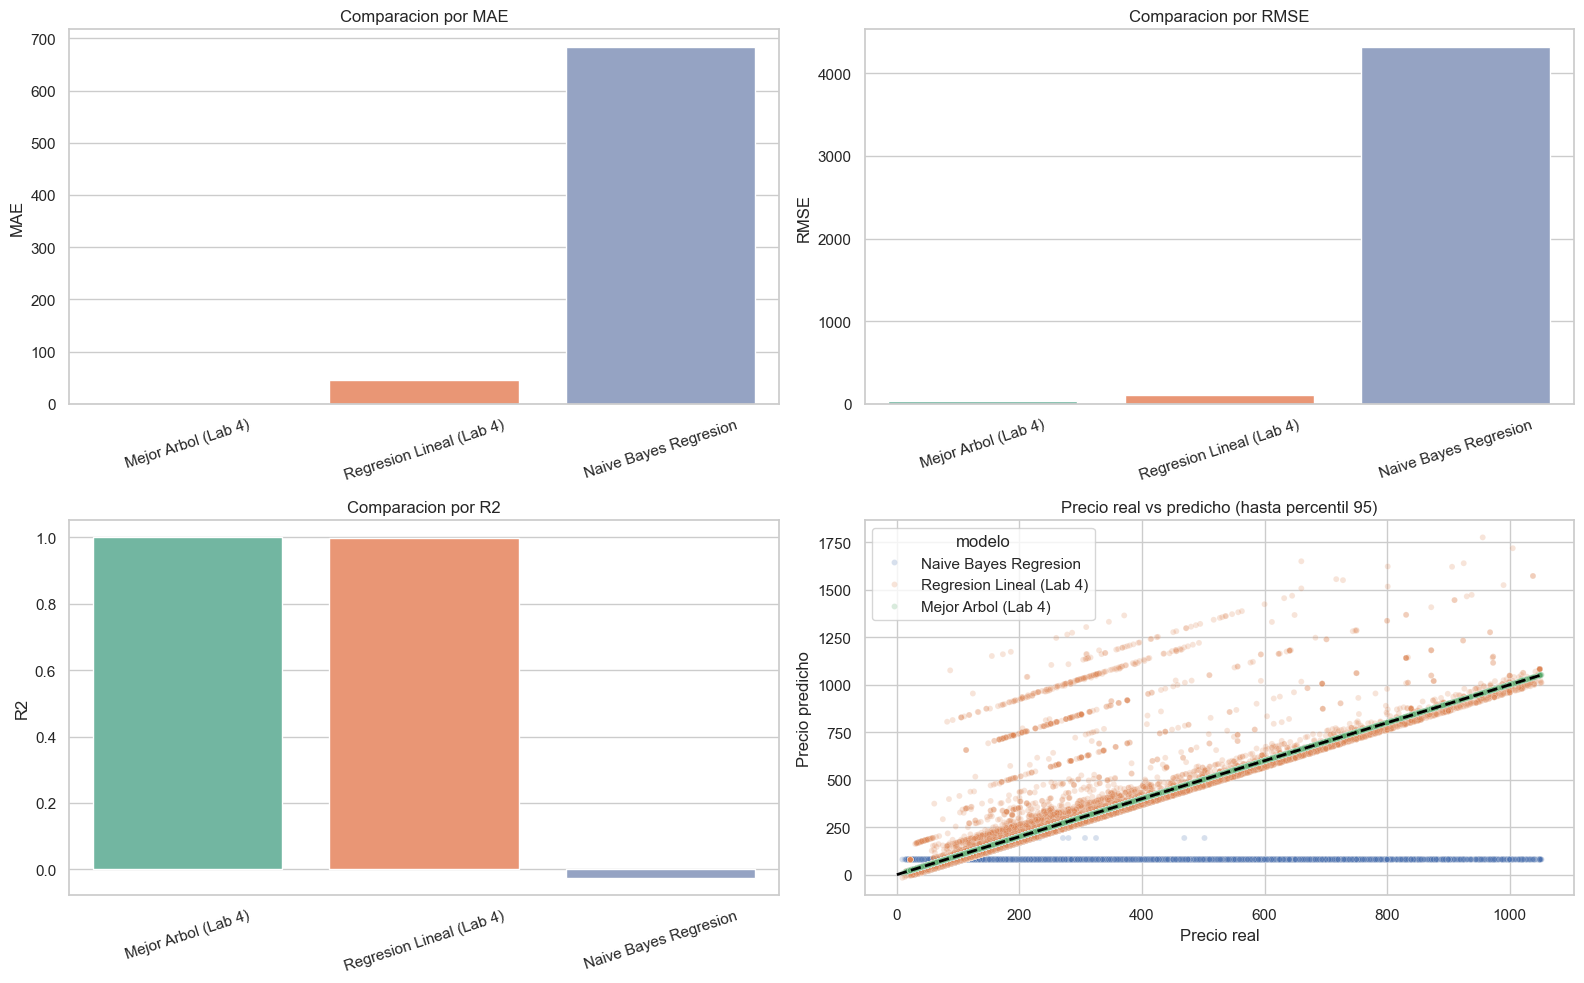

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric in zip(axes.flat[:3], ["MAE", "RMSE", "R2"]):
    sns.barplot(
        data=comparison_df,
        x="modelo",
        y=metric,
        hue="modelo",
        dodge=False,
        legend=False,
        ax=ax,
        palette="Set2",
    )
    ax.set_title(f"Comparacion por {metric}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=18)

p95_lab4 = y_test_lab4.quantile(0.95)
mask_viz_lab4 = comparison_predictions_df["price_real"] <= p95_lab4
plot_predictions_long = comparison_predictions_df.loc[mask_viz_lab4].melt(
    id_vars="price_real",
    var_name="modelo",
    value_name="price_predicho",
)
plot_predictions_long = plot_predictions_long[plot_predictions_long["modelo"] != "price_real"]

sns.scatterplot(
    data=plot_predictions_long,
    x="price_real",
    y="price_predicho",
    hue="modelo",
    alpha=0.22,
    s=18,
    ax=axes[1, 1],
)
axes[1, 1].plot([0, p95_lab4], [0, p95_lab4], color="black", linestyle="--", linewidth=2)
axes[1, 1].set_title("Precio real vs predicho (hasta percentil 95)")
axes[1, 1].set_xlabel("Precio real")
axes[1, 1].set_ylabel("Precio predicho")

plt.tight_layout()
plt.show()


### Lectura del Inciso 3

En este inciso ya estamos comparando Naive Bayes contra los modelos reales del laboratorio anterior, pero despues de quitar variables que podian inflar artificialmente el resultado.

Eso significa que:

- `Regresion Lineal (Lab 4)` usa el mismo tipo de variables y el mismo `OneHotEncoder` del lab pasado,
- `Mejor Arbol (Lab 4)` retoma la mejor configuracion encontrada alla,
- `Naive Bayes Regresion` se vuelve a entrenar sobre esa misma base usando una aproximacion por intervalos de precio y mediana por grupo, para que la comparacion si sea pareja y mas estable,
- la exclusion de `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d` ayuda a que las metricas sean mas creibles.

La conclusion principal debe salir de `comparison_df` y de la grafica `precio real vs predicho`. Si el arbol vuelve a quedar arriba, eso refuerza la idea de que el precio se comporta mejor con relaciones no lineales que con un modelo lineal o con Naive Bayes, pero ahora sin depender de variables con posible fuga.


## Inciso 4 - Modelo de Clasificacion con Categoria de Precio

Como en el dataset no existe una columna ya creada para `barata`, `media` y `cara`, construiremos esa variable categorizando `price` en tres grupos usando terciles.

Para evitar fuga de informacion, los puntos de corte se calculan **solo con el conjunto de entrenamiento** y luego se aplican tambien al conjunto de prueba.

In [108]:
train_price_for_bins = y_price.loc[X_train.index]
q1, q2 = train_price_for_bins.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

y_class = df_model["price_category"]
y_train_class = y_class.loc[X_train.index]
y_test_class = y_class.loc[X_test.index]

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

display(y_class.value_counts().to_frame(name="conteo"))

Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 269.00


,conteo
price_category,
media,25585
barata,25414
cara,25247


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/4266491484.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, ax=axes[1], palette="Set2")


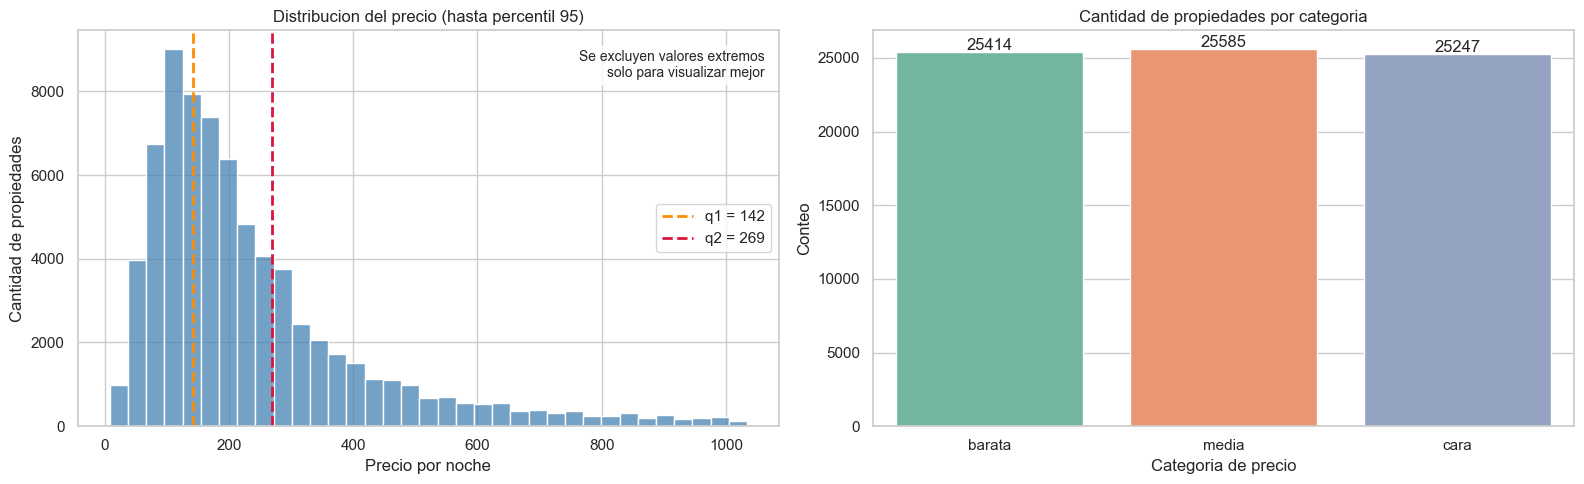

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_plot_limit = df_model["price_num"].quantile(0.95)
price_plot_data = df_model.loc[df_model["price_num"] <= price_plot_limit, "price_num"]

sns.histplot(price_plot_data, bins=35, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(q1, color="darkorange", linestyle="--", linewidth=2, label=f"q1 = {q1:.0f}")
axes[0].axvline(q2, color="crimson", linestyle="--", linewidth=2, label=f"q2 = {q2:.0f}")
axes[0].set_title("Distribucion del precio (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")
axes[0].legend()
axes[0].text(
    0.98,
    0.95,
    "Se excluyen valores extremos\nsolo para visualizar mejor",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

category_counts = df_model["price_category"].value_counts().reindex(["barata", "media", "cara"])
sns.barplot(x=category_counts.index, y=category_counts.values, ax=axes[1], palette="Set2")
axes[1].set_title("Cantidad de propiedades por categoria")
axes[1].set_xlabel("Categoria de precio")
axes[1].set_ylabel("Conteo")

for i, value in enumerate(category_counts.values):
    axes[1].text(i, value + 150, f"{int(value)}", ha="center")

plt.tight_layout()
plt.show()

In [110]:
X_train_cls_imp = X_train_imp.copy()
X_test_cls_imp = X_test_imp.copy()

nb_classifier = GaussianNB()
nb_classifier.fit(X_train_cls_imp, y_train_class)

y_pred_class = nb_classifier.predict(X_test_cls_imp)

classification_preview = pd.DataFrame(
    {
        "categoria_real": y_test_class.values,
        "categoria_predicha": y_pred_class,
    }
)

display(classification_preview.head(15))

,categoria_real,categoria_predicha
0,media,barata
1,cara,barata
2,barata,barata
3,barata,barata
4,media,barata
5,cara,barata
6,media,barata
7,media,barata
8,barata,barata
9,barata,barata


### Lectura del Inciso 4

Con esto ya queda construido el modelo de clasificacion con Naive Bayes usando la categoria de precio como variable respuesta. Los graficos ayudan a explicar dos cosas importantes:

- como se construyeron los cortes entre `barata`, `media` y `cara`,
- como queda distribuido el dataset despues de categorizar el precio.

## Inciso 5 - Eficiencia del Algoritmo para Predecir y Clasificar

En este inciso usamos el conjunto de prueba para medir la eficiencia del algoritmo tanto en regresion como en clasificacion.

Para predecir:
- `MAE`, `RMSE`, `R2`.

Para clasificar:
- `accuracy`,
- `precision macro`,
- `recall macro`,
- `f1 macro`.

In [111]:
regression_efficiency_df = comparison_df.loc[
    comparison_df["modelo"] == "Naive Bayes Regresion",
    ["modelo", "MAE", "RMSE", "R2"],
].reset_index(drop=True)

classification_metrics_df = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [
            accuracy_score(y_test_class, y_pred_class),
            precision_score(y_test_class, y_pred_class, average="macro"),
            recall_score(y_test_class, y_pred_class, average="macro"),
            f1_score(y_test_class, y_pred_class, average="macro"),
        ],
    }
)

classification_report_df = pd.DataFrame(
    classification_report(y_test_class, y_pred_class, output_dict=True)
).transpose()

print("Eficiencia del modelo de regresion (Naive Bayes):")
display(regression_efficiency_df.round(4))

print("Eficiencia del modelo de clasificacion (Naive Bayes):")
display(classification_metrics_df.round(4))

print("Detalle por clase:")
display(classification_report_df.round(4))

/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Eficiencia del modelo de regresion (Naive Bayes):


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,modelo,MAE,RMSE,R2
0,Naive Bayes Regresion,683.0307,4315.9582,-0.0253


Eficiencia del modelo de clasificacion (Naive Bayes):


,metrica,valor
0,accuracy,0.3303
1,precision_macro,0.3408
2,recall_macro,0.3339
3,f1_macro,0.1666


Detalle por clase:


,precision,recall,f1-score,support
barata,0.3300,1.0000,0.4962,5028.0000
cara,0.0000,0.0000,0.0000,5023.0000
media,0.6923,0.0017,0.0035,5199.0000
accuracy,0.3303,0.3303,0.3303,0.3303
macro avg,0.3408,0.3339,0.1666,15250.0000
weighted avg,0.3448,0.3303,0.1648,15250.0000


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_25032/3474417279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_metrics_df, x="metrica", y="valor", ax=ax, palette="Set2")


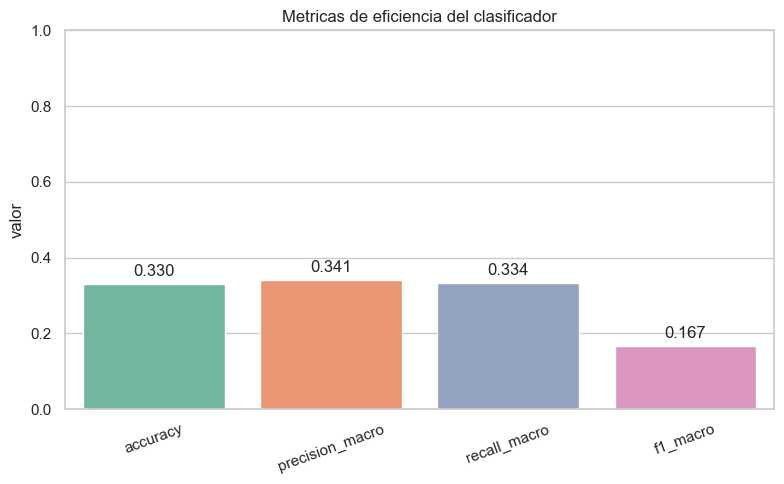

In [112]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=classification_metrics_df, x="metrica", y="valor", ax=ax, palette="Set2")
ax.set_title("Metricas de eficiencia del clasificador")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)

for i, value in enumerate(classification_metrics_df["valor"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

### Lectura del Inciso 5

La eficiencia para **predecir** debe leerse junto con la metodologia usada. Aqui Naive Bayes estima un precio representativo a partir de probabilidades sobre intervalos de precio y la mediana de cada grupo, asi que un `R2` modesto o bajo sigue siendo posible en un problema tan sesgado como este, aunque las metricas deberian ser mas estables que con la version anterior.

Para **clasificar**, las metricas permiten ver si el modelo logra separar razonablemente las categorias `barata`, `media` y `cara`. Si la `accuracy` y el `f1_macro` quedan cerca de 0.33, eso indica que el clasificador apenas esta por encima de un comportamiento casi aleatorio para tres clases. Si suben claramente por encima de ese valor, ya hay una mejor capacidad de discriminacion.

En el siguiente inciso podremos profundizar en donde se equivoca mas el clasificador usando una matriz de confusion.